In [2]:
# import core packages
import pandas as pd 
import numpy as np
import os
import snowflake.connector as snow
import pyreadstat
import xlsxwriter
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import NamedStyle

# see all columns
pd.set_option('display.max_columns', None)

# define enviro variables
user = os.environ['USER']
username = os.environ["SNOWFLAKE_USER"]
sf_pass = os.environ["SNOWFLAKE_PASSWORD"]

# set working directory
os.chdir(f"/Users/{user}/Library/CloudStorage/GoogleDrive-{user}@opportunityatwork.org/Shared drives/Insights")
# see all columns
pd.set_option('display.max_columns', None)

# establish snowflake connection
conn = snow.connect(
    user=username,
    password=sf_pass,
    account='avb99459.us-east-1',
    warehouse='OPPORTUNITYATWORK_WH',
    role='PUBLIC'
)

cur = conn.cursor()

In [52]:
import pandas as pd

# Correct function for reading CSV files
ai_exposure = pd.read_csv("Projects/Ongoing/Tulsa STAR Workforce/Input/ai_exposure.csv")

# Show the dataframe
ai_exposure.head()


,O*NET-SOC Code,Title,gpt4_alpha,gpt4_beta,gpt4_gamma,human_alpha,human_beta,human_gamma,automation,automation_acemoglu,gpt4_alt_beta,OCC_CODE
0,11-1011.00,Chief Executives,0.096774,0.451613,0.806452,0.161290,0.338710,0.516129,0.362903,0.362903,0.306452,11-1011
1,11-1011.03,Chief Sustainability Officers,0.166667,0.555556,0.944444,0.055556,0.388889,0.722222,0.513889,0.513889,0.527778,11-1011
2,11-1021.00,General and Operations Managers,0.000000,0.470588,0.941176,0.117647,0.382353,0.647059,0.470588,0.470588,0.352941,11-1021
3,11-1031.00,Legislators,0.033333,0.400000,0.766667,0.266667,0.516667,0.766667,0.308333,0.308333,0.300000,11-1031
4,11-2011.00,Advertising and Promotions Managers,0.000000,0.466667,0.933333,0.200000,0.516667,0.833333,0.508333,0.508333,0.333333,11-2011


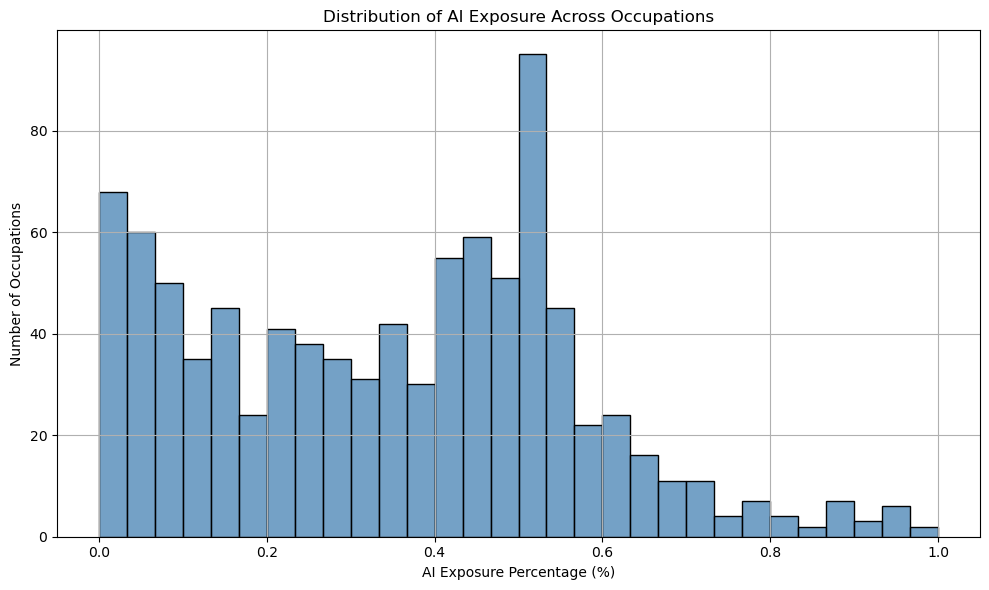

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make sure it's a numeric column
ai_exposure['gpt4_beta'] = pd.to_numeric(ai_exposure['gpt4_beta'], errors='coerce')

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(data=ai_exposure, x='gpt4_beta', bins=30, kde=False, color='steelblue')

# Formatting
plt.title('Distribution of AI Exposure Across Occupations')
plt.xlabel('AI Exposure Percentage (%)')
plt.ylabel('Number of Occupations')
plt.grid(True)
plt.tight_layout()
plt.show()

## Entry level jobs

In [3]:
query = f'''
WITH total_postings AS (
    SELECT 
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
    GROUP BY year, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT 
        EXTRACT(YEAR FROM posted)::int AS year,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE year(posted) BETWEEN 2014 AND 2024
      --AND (min_years_experience <= 1)
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed', 
          'High school or GED', 
          'Associate degree', 
          'Bachelor''s Degree'
      )
    GROUP BY year, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT 
        tp.year,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(100.0 * COALESCE(elp.entry_level_postings, 0)::numeric / NULLIF(tp.total_postings, 0), 2) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp 
        ON tp.year = elp.year AND tp.soc_2021_5_name = elp.soc_2021_5_name AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, soc_2021_5_name, entry_level_pct
'''

cur = conn.cursor().execute(query)
yoe_time_series = pd.DataFrame.from_records(iter(cur), 
                               columns=[x[0] for x in cur.description])

yoe_time_series.columns = yoe_time_series.columns.str.lower()

In [5]:
query = f'''
WITH total_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed', 
          'High school or GED', 
          'Associate degree', 
          'Bachelor''s Degree'
      )
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT 
        tp.year_month,
        tp.year,
        tp.month,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(
            100.0 * COALESCE(elp.entry_level_postings, 0)::numeric 
            / NULLIF(tp.total_postings, 0),
            2
        ) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp 
        ON tp.year_month = elp.year_month
       AND tp.soc_2021_5_name = elp.soc_2021_5_name
       AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, month, soc_2021_5_name, entry_level_pct
'''

cur = conn.cursor().execute(query)
yoe_time_series = pd.DataFrame.from_records(
    iter(cur), 
    columns=[x[0] for x in cur.description]
)

yoe_time_series.columns = yoe_time_series.columns.str.lower()


In [6]:
yoe_time_series.head(20)

,year_month,year,month,soc_2021_5_name,soc_2021_5,total_postings,entry_level_postings,entry_level_pct
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18907,840.0,4.44
1,2014-01-01,2014,1,Actors,27-2011,659,81.0,12.29
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,417,57.0,13.67
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2466,160.0,6.49
5,2014-01-01,2014,1,"Adult Basic Education, Adult Secondary Educati...",25-3011,565,42.0,7.43
6,2014-01-01,2014,1,Advertising Sales Agents,41-3011,7446,1171.0,15.73
7,2014-01-01,2014,1,Advertising and Promotions Managers,11-2011,530,36.0,6.79
8,2014-01-01,2014,1,Aerospace Engineers,17-2011,439,26.0,5.92
9,2014-01-01,2014,1,"Agents and Business Managers of Artists, Perfo...",13-1011,431,36.0,8.35


In [7]:
yoe_time_series.to_csv('/Users/khaliun/Downloads/yoe_time_series.csv', index=False)

In [56]:
# 1. Rename the occupation code column to match ai_exposure
yoe_time_series = yoe_time_series.rename(columns={'soc_2021_5': 'OCC_CODE'})

# 2. Ensure both columns are the same dtype (int or str, depending on how codes are formatted)
yoe_time_series['OCC_CODE'] = yoe_time_series['OCC_CODE'].astype(str)
ai_exposure['OCC_CODE'] = ai_exposure['OCC_CODE'].astype(str)

# 3. Merge GPT-4 exposure scores into the time series dataset
yoe_full = yoe_time_series.merge(
    ai_exposure[['OCC_CODE', 'gpt4_beta']],
    on='OCC_CODE',
    how='left'
)

# 4. View result
print(yoe_full[['OCC_CODE', 'year','month', 'entry_level_pct', 'gpt4_beta']].head())


  OCC_CODE  year  month entry_level_pct  gpt4_beta
0  13-2011  2014      1            4.46   0.550000
1  27-2011  2014      1           12.27   0.184211
2  15-2011  2014      1            4.05   0.500000
3  51-9191  2014      1           13.60   0.058824
4  11-3012  2014      1            6.51   0.416667


In [57]:
import numpy as np
import pandas as pd

# Make sure the numeric columns are floats (not Decimal, not strings)
for col in ['entry_level_pct', 'gpt4_beta']:
    if col in yoe_full.columns:
        yoe_full[col] = pd.to_numeric(yoe_full[col], errors='coerce')


In [58]:
print(yoe_full[['OCC_CODE','year','entry_level_pct','gpt4_beta']].dtypes)


OCC_CODE            object
year                 int64
entry_level_pct    float64
gpt4_beta          float64
dtype: object


In [59]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.550000
1,2014-01-01,2014,1,Actors,27-2011,660,81.0,12.27,0.184211
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05,0.500000
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,419,57.0,13.60,0.058824
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2487,162.0,6.51,0.416667
...,...,...,...,...,...,...,...,...,...
97254,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,269,71.0,26.39,0.038462
97255,2024-12-01,2024,12,Word Processors and Typists,43-9022,508,73.0,14.37,0.750000
97256,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000
97257,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000


In [60]:
import statsmodels.formula.api as smf
import numpy as np

df = yoe_full.copy()
df["month"] = df["month"].astype(int)

# month-only seasonality (11 dummies implicitly via C(month))
m = smf.ols("entry_level_pct ~ C(month)", data=df.dropna(subset=["entry_level_pct","month"])).fit()

df["entry_resid"] = m.resid

# optional: put residuals back onto a percent-like level (centered at overall mean)
df["entry_sa"] = df["entry_resid"] + df["entry_level_pct"].mean()

yoe_full = df


In [61]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.550000,-7.608598,4.304192
1,2014-01-01,2014,1,Actors,27-2011,660,81.0,12.27,0.184211,0.201402,12.114192
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05,0.500000,-8.018598,3.894192
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,419,57.0,13.60,0.058824,1.531402,13.444192
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2487,162.0,6.51,0.416667,-5.558598,6.354192
...,...,...,...,...,...,...,...,...,...,...,...
97254,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,269,71.0,26.39,0.038462,14.235622,26.148412
97255,2024-12-01,2024,12,Word Processors and Typists,43-9022,508,73.0,14.37,0.750000,2.215622,14.128412
97256,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412
97257,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412


## Occ weight share of overall in 2021

In [62]:
query = f'''
WITH occ_2021 AS (
    SELECT
        soc_2021_5,
        soc_2021_5_name,
        COUNT(DISTINCT id) AS total_postings_2021
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int = 2021
    GROUP BY soc_2021_5, soc_2021_5_name
),
total_2021 AS (
    SELECT
        SUM(total_postings_2021) AS total_postings_2021_all
    FROM occ_2021
)
SELECT
    o.soc_2021_5,
    o.soc_2021_5_name,
    o.total_postings_2021,
    (o.total_postings_2021::numeric / t.total_postings_2021_all) AS w_2021
FROM occ_2021 o
CROSS JOIN total_2021 t
ORDER BY w_2021 DESC;
'''

cur = conn.cursor().execute(query)
occ2021_weight = pd.DataFrame.from_records(iter(cur), 
                               columns=[x[0] for x in cur.description])

occ2021_weight.columns = occ2021_weight.columns.str.lower()


In [63]:
occ2021_weight

,soc_2021_5,soc_2021_5_name,total_postings_2021,w_2021
0,29-1141,Registered Nurses,2038300,0.046621
1,41-2031,Retail Salespersons,1187023,0.027150
2,53-3032,Heavy and Tractor-Trailer Truck Drivers,1186744,0.027144
3,15-1252,Software Developers,1064424,0.024346
4,43-4051,Customer Service Representatives,971311,0.022217
...,...,...,...,...
762,49-9061,Camera and Photographic Equipment Repairers,12,0.000000
763,53-7031,Dredge Operators,17,0.000000
764,51-7032,"Patternmakers, Wood",8,0.000000
765,49-2092,"Electric Motor, Power Tool, and Related Repairers",16,0.000000


In [64]:
# assume occ2021_weight already has a 'w_2021' column that sums to 1
occ2021_weight['w_2021_pct'] = (occ2021_weight['w_2021'] * 100).round(4)

print(occ2021_weight.head())

  soc_2021_5                          soc_2021_5_name  total_postings_2021  \
0    29-1141                        Registered Nurses              2038300   
1    41-2031                      Retail Salespersons              1187023   
2    53-3032  Heavy and Tractor-Trailer Truck Drivers              1186744   
3    15-1252                      Software Developers              1064424   
4    43-4051         Customer Service Representatives               971311   

     w_2021 w_2021_pct  
0  0.046621   4.662100  
1  0.027150   2.715000  
2  0.027144   2.714400  
3  0.024346   2.434600  
4  0.022217   2.221700  


In [65]:
# make sure codes match
yoe_full["OCC_CODE"] = yoe_full["OCC_CODE"].astype(str)
occ2021_weight["soc_2021_5"] = occ2021_weight["soc_2021_5"].astype(str)

yoe_full = yoe_full.merge(
    occ2021_weight[["soc_2021_5", "w_2021"]],
    left_on="OCC_CODE",
    right_on="soc_2021_5",
    how="left"
)
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.550000,-7.608598,4.304192,13-2011,0.007810
1,2014-01-01,2014,1,Actors,27-2011,660,81.0,12.27,0.184211,0.201402,12.114192,27-2011,0.000266
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05,0.500000,-8.018598,3.894192,15-2011,0.000258
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,419,57.0,13.60,0.058824,1.531402,13.444192,51-9191,0.000281
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2487,162.0,6.51,0.416667,-5.558598,6.354192,11-3012,0.000640
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97254,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,269,71.0,26.39,0.038462,14.235622,26.148412,49-9081,0.000088
97255,2024-12-01,2024,12,Word Processors and Typists,43-9022,508,73.0,14.37,0.750000,2.215622,14.128412,43-9022,0.000280
97256,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412,27-3043,0.001103
97257,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412,27-3043,0.001103


In [66]:
# pick one occupation and show all its rows (sorted by time)

occ = "13-2011"  # <-- replace with the OCC_CODE you want

one_occ = (
    yoe_full[yoe_full["OCC_CODE"].astype(str) == str(occ)]
    .sort_values(["year", "month"])
)

one_occ


,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.55,-7.608598,4.304192,13-2011,0.007810
720,2014-02-01,2014,2,Accountants and Auditors,13-2011,17482,973.0,5.57,0.55,-6.467057,5.445733,13-2011,0.007810
1435,2014-03-01,2014,3,Accountants and Auditors,13-2011,22150,1019.0,4.60,0.55,-7.479551,4.433239,13-2011,0.007810
2163,2014-04-01,2014,4,Accountants and Auditors,13-2011,20527,1007.0,4.91,0.55,-7.027811,4.884979,13-2011,0.007810
2895,2014-05-01,2014,5,Accountants and Auditors,13-2011,20613,936.0,4.54,0.55,-7.238098,4.674692,13-2011,0.007810
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93526,2024-08-01,2024,8,Accountants and Auditors,13-2011,25822,1613.0,6.25,0.55,-5.445993,6.466797,13-2011,0.007810
94276,2024-09-01,2024,9,Accountants and Auditors,13-2011,21686,1535.0,7.08,0.55,-4.845373,7.067417,13-2011,0.007810
95026,2024-10-01,2024,10,Accountants and Auditors,13-2011,23032,1250.0,5.43,0.55,-6.626831,5.285959,13-2011,0.007810
95781,2024-11-01,2024,11,Accountants and Auditors,13-2011,19789,989.0,5.00,0.55,-7.054856,4.857934,13-2011,0.007810


In [67]:
import statsmodels.formula.api as smf
import numpy as np

df = yoe_full.copy()
df["month"] = df["month"].astype(int)

# regress on month-of-year dummies (Jan omitted automatically)
m = smf.ols("entry_level_pct ~ C(month)", data=df.dropna(subset=["entry_level_pct"])).fit()

# residuals = entry-level share with seasonality removed
df["entry_resid"] = m.resid

# put residuals back on a percent-like scale (important for indexing)
df["entry_sa"] = df["entry_resid"] + df["entry_level_pct"].mean()

yoe_full = df


In [68]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,entry_resid,entry_sa,soc_2021_5,w_2021
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.550000,-7.608598,4.304192,13-2011,0.007810
1,2014-01-01,2014,1,Actors,27-2011,660,81.0,12.27,0.184211,0.201402,12.114192,27-2011,0.000266
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05,0.500000,-8.018598,3.894192,15-2011,0.000258
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,419,57.0,13.60,0.058824,1.531402,13.444192,51-9191,0.000281
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2487,162.0,6.51,0.416667,-5.558598,6.354192,11-3012,0.000640
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97254,2024-12-01,2024,12,Wind Turbine Service Technicians,49-9081,269,71.0,26.39,0.038462,14.235622,26.148412,49-9081,0.000088
97255,2024-12-01,2024,12,Word Processors and Typists,43-9022,508,73.0,14.37,0.750000,2.215622,14.128412,43-9022,0.000280
97256,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412,27-3043,0.001103
97257,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,-1.784378,10.128412,27-3043,0.001103


In [72]:
# make sure codes match
yoe_full["OCC_CODE"] = yoe_full["OCC_CODE"].astype(str)
occ2021_weight["soc_2021_5"] = occ2021_weight["soc_2021_5"].astype(str)

yoe_full = yoe_full.merge(
    occ2021_weight[["soc_2021_5", "w_2021"]],
    left_on="OCC_CODE",
    right_on="soc_2021_5",
    how="left"
)


In [73]:
import numpy as np
import pandas as pd

yoe_full["date"] = pd.to_datetime(dict(year=yoe_full.year, month=yoe_full.month, day=1))

tmp = yoe_full.dropna(subset=["entry_sa", "w_2021"]).copy()

# FIX: convert Decimal -> float
tmp["entry_sa"] = tmp["entry_sa"].astype(float)
tmp["w_2021"]   = tmp["w_2021"].astype(float)

monthly_weighted = (
    tmp.groupby("date", as_index=False)
       .apply(lambda g: pd.Series({"entry_sa_weighted": np.average(g["entry_sa"], weights=g["w_2021"])}))
       .reset_index(drop=True)
)


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_63738/576822026.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"entry_sa_weighted": np.average(g["entry_sa"], weights=g["w_2021"])}))


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_63738/1350765511.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in gm_zoom.groupby("exposure_group"):


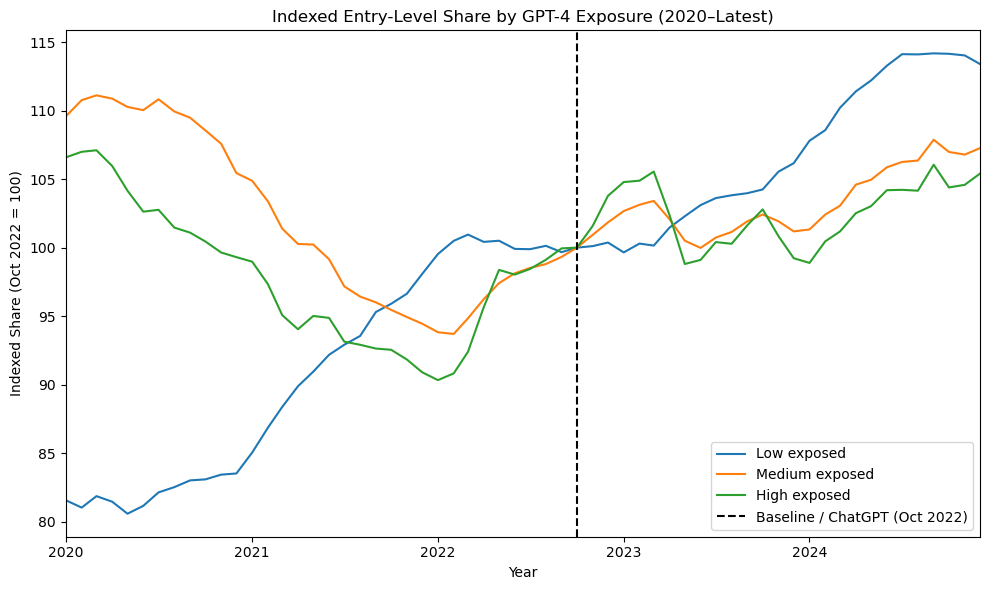

In [77]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

start = pd.Timestamp("2020-01-01")
gm_zoom = gm[gm["year_month"] >= start].copy()

plt.figure(figsize=(10,6))
for grp, g in gm_zoom.groupby("exposure_group"):
    plt.plot(g["year_month"], g["index_smooth_rebased"], label=f"{grp} exposed")

plt.axvline(pd.Timestamp("2022-10-01"), color="black", linestyle="--", label="Baseline / ChatGPT (Oct 2022)")
plt.title("Indexed Entry-Level Share by GPT-4 Exposure (2020–Latest)")
plt.ylabel("Indexed Share (Oct 2022 = 100)")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())          # yearly ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # show just the year
plt.xlim(start, gm_zoom["year_month"].max())

plt.legend()
plt.tight_layout()
plt.show()


/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_63738/1957044407.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_63738/1957044407.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, g in gm_zoom.groupby("exposure_group"):


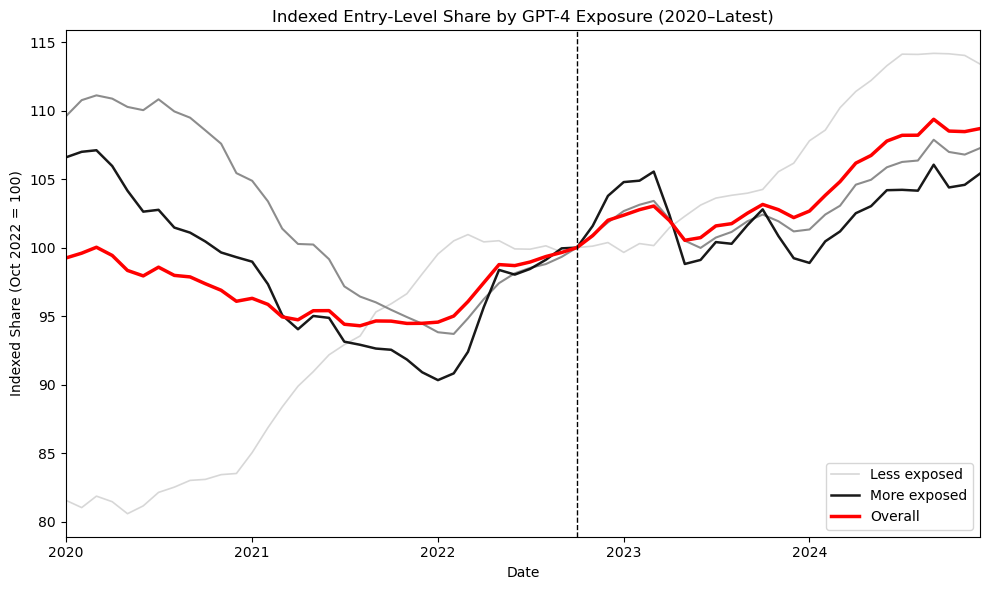

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- assume gm_zoom exists ----
# columns: year_month, exposure_group, index_smooth_rebased
# exposure_group ∈ {"Low","Medium","High"}

# 1) Overall line (average across exposure groups, Canaries-style)
overall = (
    gm_zoom.groupby("year_month", as_index=False)
           .apply(lambda g: pd.Series({
               "overall_index": g["index_smooth_rebased"].mean()
           }))
           .reset_index(drop=True)
)

# 2) Plot
plt.figure(figsize=(10,6))

# exposure-specific lines (lighter → darker)
exposure_style = {
    "Low":    {"color": "lightgray", "lw": 1.2, "label": "Less exposed"},
    "Medium": {"color": "gray",      "lw": 1.5, "label": None},
    "High":   {"color": "black",     "lw": 1.8, "label": "More exposed"},
}

for grp, g in gm_zoom.groupby("exposure_group"):
    style = exposure_style[grp]
    plt.plot(
        g["year_month"],
        g["index_smooth_rebased"],
        color=style["color"],
        linewidth=style["lw"],
        alpha=0.9,
        label=style["label"]
    )

# overall (thick red)
plt.plot(
    overall["year_month"],
    overall["overall_index"],
    color="red",
    linewidth=2.5,
    label="Overall"
)

# baseline
baseline_date = pd.Timestamp("2022-10-01")
plt.axvline(baseline_date, color="black", linestyle="--", linewidth=1)

# formatting
plt.title("Indexed Entry-Level Share by GPT-4 Exposure (2020–Latest)")
plt.ylabel("Indexed Share (Oct 2022 = 100)")
plt.xlabel("Date")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xlim(pd.Timestamp("2020-01-01"), gm_zoom["year_month"].max())

plt.legend(frameon=True)
plt.tight_layout()
plt.show()


## Plots

/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_951/680451899.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(["year_month", "exposure_group"], as_index=False)
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_951/680451899.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/6h/l1_lq8b96y72mkslk3phrlpw0000gn/T/ipykernel_951/680451899.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in 

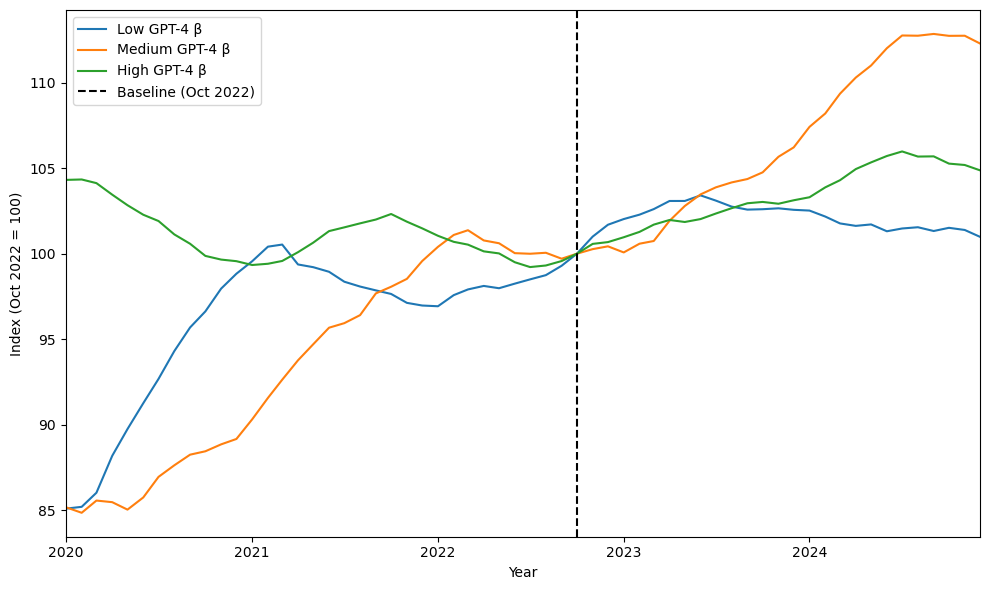

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Clean types ---
yoe_full["year_month"] = pd.to_datetime(yoe_full["year_month"])
yoe_full["gpt4_beta"] = pd.to_numeric(yoe_full["gpt4_beta"], errors="coerce")
yoe_full["entry_sa"]  = pd.to_numeric(yoe_full["entry_sa"], errors="coerce")
yoe_full["w_2021"]    = pd.to_numeric(yoe_full["w_2021"], errors="coerce")

# --- Exposure groups (3 bins) ---
yoe_full["exposure_group"] = pd.qcut(
    yoe_full["gpt4_beta"], q=3, labels=["Low", "Medium", "High"]
)

# --- Weighted monthly average within exposure group (using fixed 2021 weights) ---
tmp = yoe_full.dropna(subset=["year_month", "exposure_group", "entry_sa", "w_2021"]).copy()

group_month = (
    tmp.groupby(["year_month", "exposure_group"], as_index=False)
       .apply(lambda g: pd.Series({
           "entry_sa_wavg": np.average(g["entry_sa"], weights=g["w_2021"])
       }))
       .reset_index(drop=True)
)

# --- Index to Oct 2022 = 100 (within each group) ---
baseline_date = pd.Timestamp("2022-10-01")
base = (group_month[group_month["year_month"].eq(baseline_date)]
        [["exposure_group", "entry_sa_wavg"]]
        .rename(columns={"entry_sa_wavg": "base"}))

group_month = group_month.merge(base, on="exposure_group", how="left")
group_month["index"] = (group_month["entry_sa_wavg"] / group_month["base"]) * 100

# --- Smooth (12-month MA), then REBASE smoothed so Oct 2022 = 100 ---
group_month = group_month.sort_values(["exposure_group", "year_month"]).copy()
group_month["index_smooth"] = (
    group_month.groupby("exposure_group")["index"]
              .transform(lambda s: s.rolling(window=12, min_periods=6).mean())
)

base_s = (group_month[group_month["year_month"].eq(baseline_date)]
          [["exposure_group", "index_smooth"]]
          .rename(columns={"index_smooth": "base_smooth"}))

group_month = group_month.merge(base_s, on="exposure_group", how="left")
group_month["index_smooth_rebased"] = (group_month["index_smooth"] / group_month["base_smooth"]) * 100

# --- Zoom from 2020 onward ---
start = pd.Timestamp("2020-01-01")
gm = group_month[group_month["year_month"] >= start].copy()

# --- Plot with yearly ticks ---
plt.figure(figsize=(10,6))
for grp, g in gm.groupby("exposure_group"):
    plt.plot(g["year_month"], g["index_smooth_rebased"], label=f"{grp} GPT-4 β")

plt.axvline(baseline_date, color="black", linestyle="--", label="Baseline (Oct 2022)")
#plt.title("Indexed Entry-Level Share by GPT-4 Exposure (Residualized + 2021-weighted)")
plt.ylabel("Index (Oct 2022 = 100)")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xlim(start, gm["year_month"].max())

plt.legend()
plt.tight_layout()
plt.show()


## ai exposed occ - entry share

In [69]:
query = f'''
WITH total_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
      AND soc_2021_5_name = 'Software Developers'
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
      AND soc_2021_5_name = 'Software Developers'
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed', 
          'High school or GED', 
          'Associate degree', 
          'Bachelor''s Degree'
      )
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT 
        tp.year_month,
        tp.year,
        tp.month,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(
            100.0 * COALESCE(elp.entry_level_postings, 0)::numeric 
            / NULLIF(tp.total_postings, 0),
            2
        ) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp 
        ON tp.year_month = elp.year_month
       AND tp.soc_2021_5_name = elp.soc_2021_5_name
       AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, month, soc_2021_5_name, entry_level_pct
'''
cur = conn.cursor().execute(query)
sofw_dev = pd.DataFrame.from_records(
    iter(cur), 
    columns=[x[0] for x in cur.description]
)

sofw_dev.columns = sofw_dev.columns.str.lower()

In [71]:
sofw_dev


,year_month,year,month,soc_2021_5_name,soc_2021_5,total_postings,entry_level_postings,entry_level_pct
0,2014-01-01,2014,1,Software Developers,15-1252,49767,1350,2.71
1,2014-02-01,2014,2,Software Developers,15-1252,42719,1337,3.13
2,2014-03-01,2014,3,Software Developers,15-1252,50179,1398,2.79
3,2014-04-01,2014,4,Software Developers,15-1252,59352,1411,2.38
4,2014-05-01,2014,5,Software Developers,15-1252,54731,1262,2.31
...,...,...,...,...,...,...,...,...
127,2024-08-01,2024,8,Software Developers,15-1252,52918,725,1.37
128,2024-09-01,2024,9,Software Developers,15-1252,52556,1119,2.13
129,2024-10-01,2024,10,Software Developers,15-1252,59488,977,1.64
130,2024-11-01,2024,11,Software Developers,15-1252,44905,779,1.73


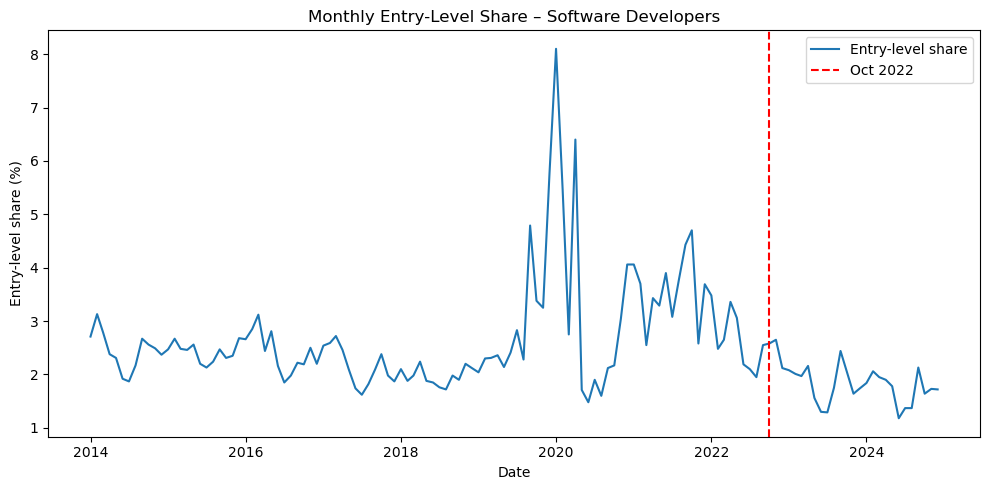

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

sofw_dev['year_month'] = pd.to_datetime(sofw_dev['year_month'])
sofw_dev = sofw_dev.sort_values('year_month')

plt.figure(figsize=(10, 5))
plt.plot(sofw_dev['year_month'], sofw_dev['entry_level_pct'], label='Entry-level share')

# 🔴 Vertical red line at Oct 2022
oct_2022 = pd.to_datetime('2022-10-01')
plt.axvline(oct_2022, color='red', linestyle='--', label='Oct 2022')

plt.xlabel('Date')
plt.ylabel('Entry-level share (%)')
plt.title('Monthly Entry-Level Share – Software Developers')
plt.legend()
plt.tight_layout()
plt.show()


In [74]:
yoe_full

,year_month,year,month,soc_2021_5_name,OCC_CODE,total_postings,entry_level_postings,entry_level_pct,gpt4_beta,post,baseline_oct22,indexed_share,exposure_group,w_2021_pct
0,2014-01-01,2014,1,Accountants and Auditors,13-2011,18920,843.0,4.46,0.550000,0,5.50,81.090909,High,0.7810
1,2014-01-01,2014,1,Actors,27-2011,660,81.0,12.27,0.184211,0,7.41,165.587045,Low,0.0266
2,2014-01-01,2014,1,Actuaries,15-2011,666,27.0,4.05,0.500000,0,4.77,84.905660,Medium,0.0258
3,2014-01-01,2014,1,Adhesive Bonding Machine Operators and Tenders,51-9191,419,57.0,13.60,0.058824,0,19.56,69.529652,Low,0.0281
4,2014-01-01,2014,1,Administrative Services Managers,11-3012,2487,162.0,6.51,0.416667,0,7.27,89.546080,Medium,0.0640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162960,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,1,6.42,161.526480,High,0.1103
162961,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,1,6.42,161.526480,High,0.1103
162962,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,1,6.42,161.526480,High,0.1103
162963,2024-12-01,2024,12,Writers and Authors,27-3043,2035,211.0,10.37,0.875000,1,6.42,161.526480,High,0.1103


In [75]:
query = f'''
WITH total_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS total_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
      AND soc_2021_5_name = 'Data Scientists'
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_postings AS (
    SELECT 
        date_trunc('month', posted)::date AS year_month,
        EXTRACT(YEAR FROM posted)::int AS year,
        EXTRACT(MONTH FROM posted)::int AS month,
        soc_2021_5_name,
        soc_2021_5,
        COUNT(DISTINCT id) AS entry_level_postings
    FROM emsi.us.postings
    WHERE EXTRACT(YEAR FROM posted)::int BETWEEN 2014 AND 2024
      AND soc_2021_5_name = 'Data Scientists'
      AND (
          (job_seniority_name = 'Junior' AND min_years_experience IS NULL)
          OR min_years_experience <= 1
      )
      AND min_edulevels_name IN (
          'No Education Listed', 
          'High school or GED', 
          'Associate degree', 
          'Bachelor''s Degree'
      )
    GROUP BY year_month, year, month, soc_2021_5_name, soc_2021_5
),

entry_level_share AS (
    SELECT 
        tp.year_month,
        tp.year,
        tp.month,
        tp.soc_2021_5_name,
        tp.soc_2021_5,
        tp.total_postings,
        elp.entry_level_postings,
        ROUND(
            100.0 * COALESCE(elp.entry_level_postings, 0)::numeric 
            / NULLIF(tp.total_postings, 0),
            2
        ) AS entry_level_pct
    FROM total_postings tp
    LEFT JOIN entry_level_postings elp 
        ON tp.year_month = elp.year_month
       AND tp.soc_2021_5_name = elp.soc_2021_5_name
       AND tp.soc_2021_5 = elp.soc_2021_5
)

SELECT *
FROM entry_level_share
WHERE total_postings > 100
ORDER BY year, month, soc_2021_5_name, entry_level_pct
'''
cur = conn.cursor().execute(query)
ds = pd.DataFrame.from_records(iter(cur), columns=[x[0] for x in cur.description])
ds.columns = ds.columns.str.lower()


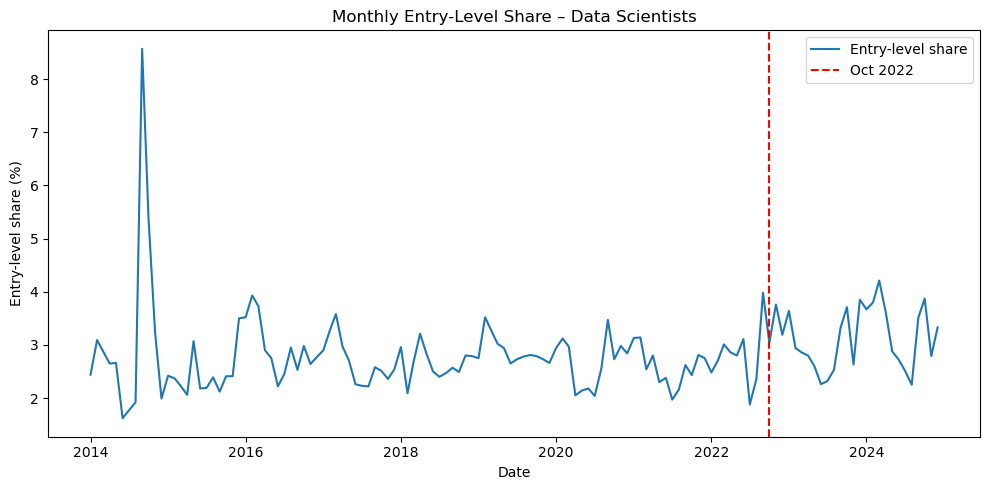

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

ds['year_month'] = pd.to_datetime(ds['year_month'])
ds = ds.sort_values('year_month')

plt.figure(figsize=(10, 5))
plt.plot(ds['year_month'], ds['entry_level_pct'], label='Entry-level share')

# Red line at Oct 2022
oct_2022 = pd.to_datetime('2022-10-01')
plt.axvline(oct_2022, color='red', linestyle='--', label='Oct 2022')

plt.xlabel('Date')
plt.ylabel('Entry-level share (%)')
plt.title('Monthly Entry-Level Share – Data Scientists')
plt.legend()
plt.tight_layout()
plt.show()


## Regression

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Use the UNSMOOTHED index if you have it (recommended for inference)
df_es = group_month.copy()
yvar = "index"
if yvar not in df_es.columns:
    yvar = "index_smooth_rebased"  # fallback

df_es["year_month"] = pd.to_datetime(df_es["year_month"])
df_es = df_es.dropna(subset=["year_month", "exposure_group", yvar]).copy()

baseline_date = pd.Timestamp("2022-10-01")
df_es["event_time"] = (
    (df_es["year_month"].dt.year - baseline_date.year) * 12
    + (df_es["year_month"].dt.month - baseline_date.month)
).astype(int)

# event window (edit as you like)
min_k, max_k = -24, 24
df_es = df_es[df_es["event_time"].between(min_k, max_k)].copy()

# Reference categories
df_es["exposure_group"] = pd.Categorical(df_es["exposure_group"], categories=["Low","Medium","High"], ordered=True)

# Drop baseline k=0 so coefficients are relative to Oct 2022
df_es = df_es[df_es["event_time"] != 0].copy()
df_es["event_time"] = df_es["event_time"].astype(int).astype(str)  # treat as categorical safely

# Event-study: y ~ event_time FE + (event_time × group) interactions
# Low is reference group; event_time base is implicitly absorbed because we dropped k=0
formula = f"{yvar} ~ C(event_time) + C(event_time):C(exposure_group, Treatment('Low'))"
res = smf.ols(formula, data=df_es).fit(cov_type="HC1")

# ---- Extract event-time interaction coefficients for Medium/High vs Low ----
params = res.params
bse = res.bse

rows = []
for term in params.index:
    # Terms look like: C(event_time)[T.-1]:C(exposure_group, Treatment('Low'))[T.High]
    if "C(event_time)" in term and ":C(exposure_group" in term:
        k = term.split("C(event_time)[T.")[1].split("]")[0]
        grp = term.split("[T.")[-1].replace("]", "")  # High or Medium
        rows.append({
            "event_time": int(k),
            "group": grp,
            "beta": float(params[term]),
            "se": float(bse[term]),
        })

coef = pd.DataFrame(rows)
coef["lo"] = coef["beta"] - 1.96 * coef["se"]
coef["hi"] = coef["beta"] + 1.96 * coef["se"]

# Add baseline point (0) at zero for plotting
coef = pd.concat([
    coef,
    pd.DataFrame([{"event_time":0,"group":"Medium","beta":0,"se":np.nan,"lo":0,"hi":0},
                  {"event_time":0,"group":"High","beta":0,"se":np.nan,"lo":0,"hi":0}])
], ignore_index=True)

coef = coef.sort_values(["group","event_time"])

# ---- Plot ----
plt.figure(figsize=(10,6))
for grp in ["Medium","High"]:
    g = coef[coef["group"] == grp].sort_values("event_time")
    plt.plot(g["event_time"], g["beta"], label=f"{grp} vs Low")
    gg = g.dropna(subset=["se"])
    plt.fill_between(gg["event_time"], gg["lo"], gg["hi"], alpha=0.2)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"Event Study: {yvar} (differences vs Low, baseline Oct 2022)")
plt.xlabel("Months since Oct 2022")
plt.ylabel("Difference in index (points)")
plt.legend()
plt.tight_layout()
plt.show()

# If you want the coefficient table:
coef


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1993: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1993: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1972: RuntimeWarning: invalid value encountered in multiply
  scale[:, None] * self.model.pinv_wexog.T)


IndexError: list index out of range

## reg old

In [77]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# 1. Clean regression sample: valid index, exposure, weight
df_reg = yoe_full.copy()
df_reg['indexed_share'] = pd.to_numeric(df_reg['indexed_share'], errors='coerce')
df_reg['gpt4_beta']     = pd.to_numeric(df_reg['gpt4_beta'], errors='coerce')
df_reg['w_2021_pct']    = pd.to_numeric(df_reg['w_2021_pct'], errors='coerce')

df_reg = df_reg[
    df_reg['indexed_share'].notna() &
    df_reg['gpt4_beta'].notna() &
    df_reg['w_2021_pct'].notna()
].copy()

# 2. Make a string time fixed-effect variable (month FE)
df_reg['ym_str'] = df_reg['year_month'].astype(str)

# 3. DiD-style regression with occ FE + month FE, weighted by 2021 shares
#    Outcome: indexed_share (baseline = 100 in Oct 2022)
#    Key coefficient: post:gpt4_beta  → differential change after Oct 2022 for more exposed occs
model = smf.wls(
    'indexed_share ~ post * gpt4_beta + C(OCC_CODE) + C(ym_str)',
    data=df_reg,
    weights=df_reg['w_2021_pct']    # employment-weighted
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['OCC_CODE']})

print(model.summary())


                            WLS Regression Results                            
Dep. Variable:          indexed_share   R-squared:                       0.375
Model:                            WLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                -6.016e-12
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               1.00
Time:                        13:54:56   Log-Likelihood:            -8.2379e+05
No. Observations:              158348   AIC:                         1.649e+06
Df Residuals:                  157606   BIC:                         1.656e+06
Df Model:                         741                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 742, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1885: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


In [78]:
# See all coefficients (long)
model.params

# Just the ones you care about
model.params[['gpt4_beta', 'post:gpt4_beta']]
model.bse[['gpt4_beta', 'post:gpt4_beta']]      # standard errors
model.pvalues[['gpt4_beta', 'post:gpt4_beta']]  # p-values


gpt4_beta         0.993804
post:gpt4_beta    0.918328
dtype: float64